# Trabalho Prático 1 - ANADI

## 4.2 - Manipulação de dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import ttest_ind

### 4.2.1 - Processamento da Iluminação Pública (IP_data)

In [2]:
print("\n--- 4.2.1: Processamento da Iluminação Pública ---")

# 0. Ler o ficheiro de dados
# (Ajusta o nome do ficheiro para .xlsx ou .csv conforme o que estiveres a usar no teu código)
ip = pd.read_excel("IP_data.xlsx")

# 1. Criar variável binária Is_Ineficiente
ip["Is_Ineficiente"] = ip["Tipo de Lâmpada"].isin(["Sódio", "Mercúrio"]).astype(int)

# 2. Criar variável Potência kW
# Atenção ao nome real da coluna no ficheiro: Potência Instalada Total (W)
ip["Potência kW"] = ip["Potência Instalada Total (W)"] / 1000

# Coluna auxiliar para calcular a potência ineficiente mais facilmente no groupby
ip["Potencia_Inef_Temp"] = ip["Potência kW"] * ip["Is_Ineficiente"]

# 3. Agrupar por CodDistritoConcelho
ip_group = ip.groupby("CodDistritoConcelho").agg(
    P_IP_Total=("Potência kW", "sum"),
    P_IP_Inef=("Potencia_Inef_Temp", "sum")
).reset_index()

# Opcional: Apagar a coluna temporária do dataframe original (boas práticas)
ip = ip.drop(columns=["Potencia_Inef_Temp"])

print("Resultado do agrupamento IP (Primeiras linhas):")
print(ip_group.head())


--- 4.2.1: Processamento da Iluminação Pública ---
Resultado do agrupamento IP (Primeiras linhas):
   CodDistritoConcelho   P_IP_Total  P_IP_Inef
0                  101   910.887701    244.320
1                  102   451.711801     28.020
2                  103   657.071801     73.545
3                  104   585.974400    115.720
4                  105  1055.192001    144.420


### 4.2.2 - Processamento dos Postos de Transformação (PTD_data)

No ficheiro PTD, o nível de utilização dos postos de transformação encontrava-se representado em
intervalos percentuais (ex.: 60%-79%). Para efeitos de análise quantitativa, foi considerado o limite superior do intervalo, convertendo os valores para formato decimal (ex.: 0.79). Valores representados como intervalos percentuais foram convertidos considerando o limite superior do intervalo. Valores indicados como "<20" foram aproximados para 0.20 e valores "N/D" foram tratados como dados omissos.

Por fim, agrupou-se por concelho os dados do ficheiro PTDA para obter 3 dados importantes para cálculos futuros: soma da potência instalada de todos os PTDs do concelho, média do Nível de Utilização de todos os PTDs do concelho, número de PTDs de cada concelho.

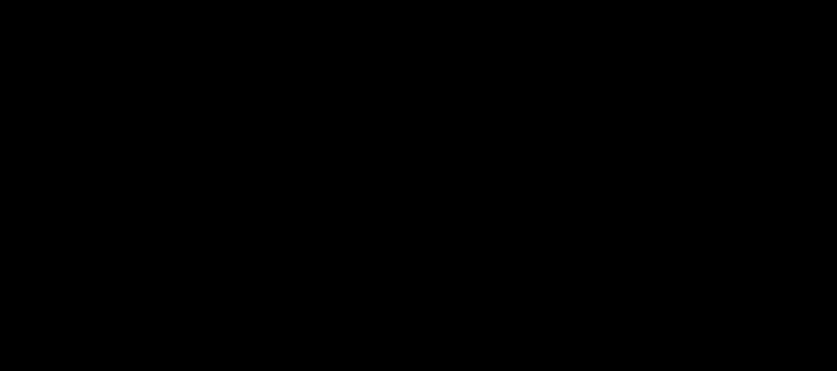
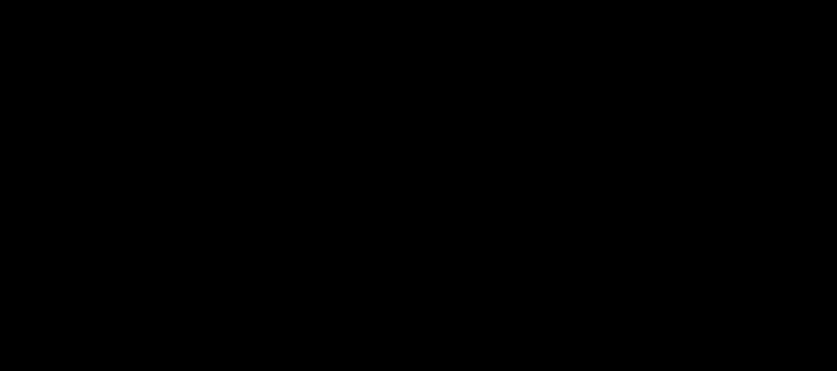
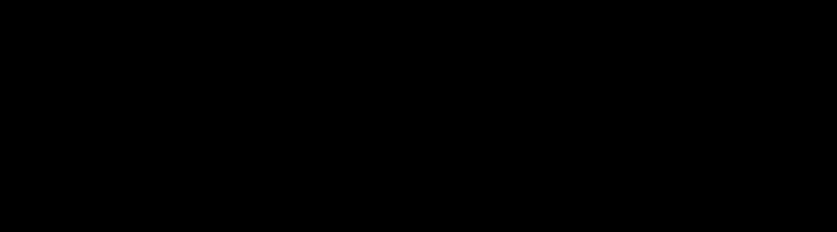
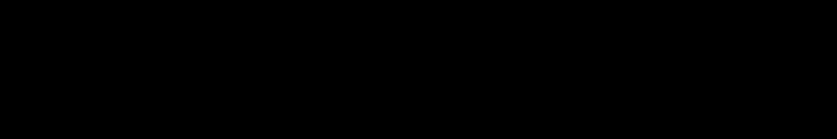

In [3]:
def converter_utilizacao(valor):

    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # casos tipo "60%-79%"
    if "-" in valor and "%" in valor:
        return float(valor.split("-")[1].replace("%", "")) / 100

    # caso "+100%"
    if "+" in valor:
        return 1.0

    # caso "<20"
    if "<" in valor:
        return 0.20

    # caso "N/D"
    if "N/D" in valor:
        return np.nan

    return np.nan

ptd = pd.read_excel("PTD_data.xlsx")

ptd["Utilizacao_decimal"] = ptd["Nível de Utilização [%]"].apply(converter_utilizacao)

print("4.2.2: Conversão de nível de utilização para decimal:")
print(ptd[["Nível de Utilização [%]", "Utilizacao_decimal"]].head())

ptd_group = ptd.groupby("CodDistritoConcelho").agg(

    Cap_PTD=("Potência instalada [kVA]", "sum"),

    Util_Media=("Utilizacao_decimal", "mean"),

    N_PTDs=("Código de Instalação", "count")

).reset_index()

print()
print("4.2.2: Agrupar por Código Distrito Concelho")
print(ptd_group.head())

4.2.2: Conversão de nível de utilização para decimal:
  Nível de Utilização [%]  Utilizacao_decimal
0                 60%-79%                0.79
1                 60%-79%                0.79
2                 60%-79%                0.79
3                   +100%                1.00
4                  0%-19%                0.19

4.2.2: Agrupar por Código Distrito Concelho
   CodDistritoConcelho  Cap_PTD  Util_Media  N_PTDs
0                  101   105715    0.477593     388
1                  102    54540    0.469948     194
2                  103    55628    0.543009     223
3                  104    41884    0.527387     236
4                  105   197485    0.475475     509


### 4.2.3 - Variáveis do Novo Dataset

In [4]:
df_final = pd.merge(ip_group, ptd_group, on="CodDistritoConcelho", how="inner")

df_final["Delta_PLED"] = df_final["P_IP_Inef"] * 0.65
df_final["PFolga"] = (df_final["Cap_PTD"] * 0.92) * (1 - df_final["Util_Media"])
df_final["PVE"] = df_final["N_PTDs"] * 22 * 0.60
df_final["D"] = df_final["PFolga"] + df_final["Delta_PLED"] - df_final["PVE"]
df_final["Rate_Ineficiencia"] = df_final["P_IP_Inef"] / df_final["P_IP_Total"]

## 4.3 - Análise e Exploração de dados

### 4.3.1 - Mix tecnológico (LED vs Convencional)


--- 4.3.1: Mix tecnológico da iluminação pública ---
Potência total por tecnologia:
Tecnologia
Convencional (Sódio/Mercúrio)     61708.65900
LED / Outras eficientes          118799.21451
Name: Potência kW, dtype: float64


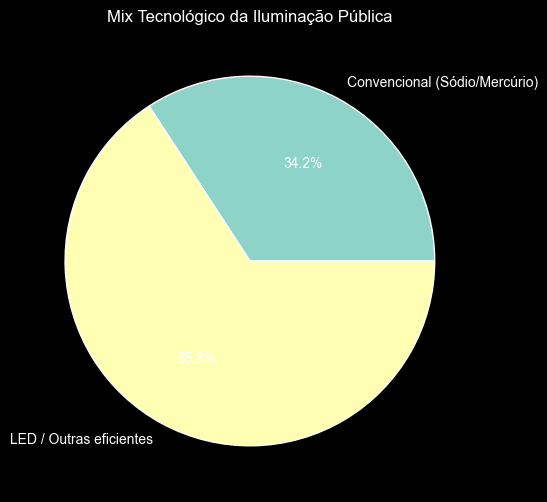


Concelhos com maior potência ineficiente:
     CodDistritoConcelho  P_IP_Inef
151                 1105   3494.920
157                 1111   2764.985
156                 1110   2757.620
185                 1308   2509.780
219                 1503   2464.555
61                   503   1807.900
72                   603   1714.755
183                 1306   1530.430
108                  808   1518.075
190                 1313   1513.920


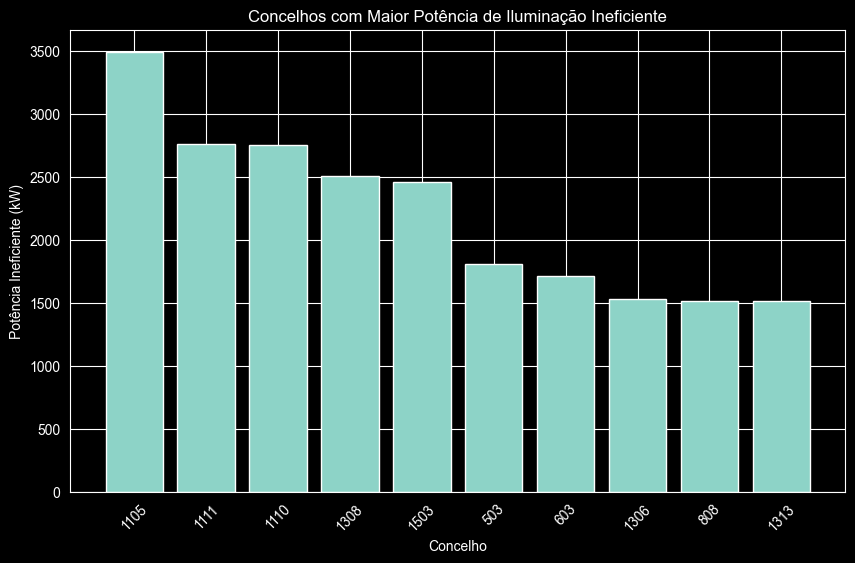

In [5]:
print("\n--- 4.3.1: Mix tecnológico da iluminação pública ---")

# classificar tecnologia
ip["Tecnologia"] = ip["Is_Ineficiente"].map({
    1: "Convencional (Sódio/Mercúrio)",
    0: "LED / Outras eficientes"
})

# somar potência por tecnologia
mix_tecnologico = ip.groupby("Tecnologia")["Potência kW"].sum()

print("Potência total por tecnologia:")
print(mix_tecnologico)

# gráfico pie
plt.figure(figsize=(6,6))
mix_tecnologico.plot(kind="pie", autopct="%1.1f%%")

plt.title("Mix Tecnológico da Iluminação Pública")
plt.ylabel("")

plt.show()


# verificar concentração da potência ineficiente por município
top_ineficientes = ip_group.sort_values("P_IP_Inef", ascending=False).head(10)

print()
print("Concelhos com maior potência ineficiente:")
print(top_ineficientes[["CodDistritoConcelho", "P_IP_Inef"]])

plt.figure(figsize=(10,6))
plt.bar(top_ineficientes["CodDistritoConcelho"].astype(str), top_ineficientes["P_IP_Inef"])

plt.title("Concelhos com Maior Potência de Iluminação Ineficiente")
plt.xlabel("Concelho")
plt.ylabel("Potência Ineficiente (kW)")

plt.xticks(rotation=45)

plt.show()

### 4.3.2 - Boxplots por Distrito


--- 4.3.2: Boxplots de Utilização por Distrito ---


<Figure size 1000x600 with 0 Axes>

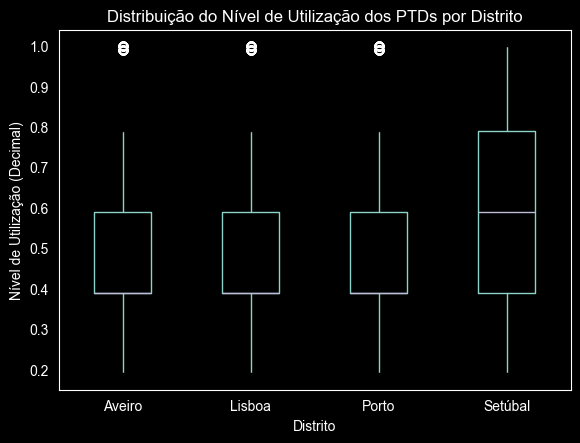

Variabilidade (Desvio Padrão) da utilização por distrito:
Distrito
Setúbal    0.254050
Lisboa     0.242931
Porto      0.239539
Aveiro     0.237937
Name: Utilizacao_decimal, dtype: float64


In [6]:
print("\n--- 4.3.2: Boxplots de Utilização por Distrito ---")

# 1. Extrair o código do Distrito (os primeiros dígitos do CodDistritoConcelho)
# Como o CodDistritoConcelho tem 3 ou 4 dígitos, uma divisão inteira por 100 dá-nos o Distrito.
ptd["CodDistrito"] = ptd["CodDistritoConcelho"] // 100

# 2. Mapear o código para o nome do Distrito correspondente
mapa_distritos = {
    1: "Aveiro",
    11: "Lisboa",
    13: "Porto",
    15: "Setúbal"
}
ptd["Distrito"] = ptd["CodDistrito"].map(mapa_distritos)

# 3. Definir os distritos que queremos analisar e remover valores nulos
distritos_alvo = ["Lisboa", "Porto", "Aveiro", "Setúbal"]
ptd_filtrado = ptd[ptd["Distrito"].isin(distritos_alvo)].dropna(subset=["Utilizacao_decimal"])

# 4. Criar a caixa de bigodes (boxplot)
plt.figure(figsize=(10, 6))
ptd_filtrado.boxplot(column="Utilizacao_decimal", by="Distrito", grid=False)

# Formatar o gráfico
plt.title("Distribuição do Nível de Utilização dos PTDs por Distrito")
plt.suptitle("") # Remove o subtítulo automático
plt.xlabel("Distrito")
plt.ylabel("Nível de Utilização (Decimal)")

# Mostrar o gráfico (não te esqueças de guardar ou fazer print screen para o relatório!)
plt.show()

# 5. Calcular o desvio padrão para responder à pergunta "maior variabilidade"
variabilidade = ptd_filtrado.groupby("Distrito")["Utilizacao_decimal"].std().sort_values(ascending=False)
print("Variabilidade (Desvio Padrão) da utilização por distrito:")
print(variabilidade)

### 4.3.3 - Quantificar valores omissos ou indeterminados

Foi analisada a presença de valores omissos ou indeterminados na variável "Nível de Utilização [%]", embora outras variáveis apresentem valores "N/D" ou "<20", estas não foram consideradas na análise por não integrarem as métricas utilizadas neste estudo.

Para identificar possíveis outliers nos níveis de ocupação da rede foi utilizado um boxplot da variável convertida para formato decimal. O gráfico permitiu observar a dispersão dos dados e a presença de alguns valores extremos acima do intervalo interquartil.


4.3.3: Quantidade de valores omissos ou indeterminados:
Valores N/D: 3064
Valores <20: 0
Total de registos: 72027
Percentagem N/D: 4.25 %
Percentagem <20: 0.0 %


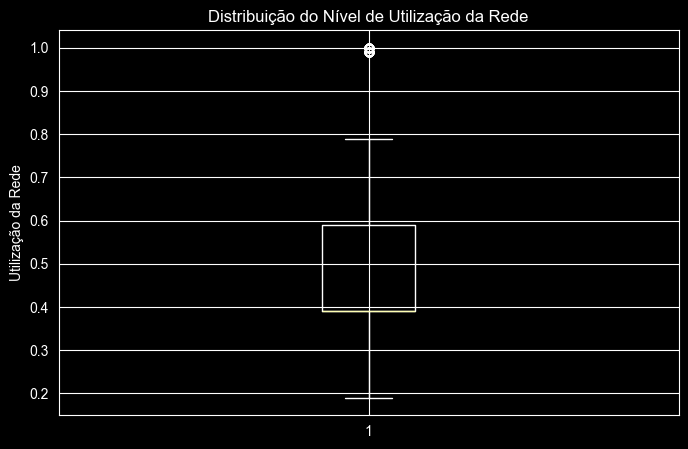

In [7]:
nd_count = (ptd["Nível de Utilização [%]"] == "N/D").sum()
lt20_count = ptd["Nível de Utilização [%]"].astype(str).str.contains("<20").sum()

total = len(ptd)

print()
print("4.3.3: Quantidade de valores omissos ou indeterminados:")
print("Valores N/D:", nd_count)
print("Valores <20:", lt20_count)
print("Total de registos:", total)

print("Percentagem N/D:", round((nd_count/total)*100,2), "%")
print("Percentagem <20:", round((lt20_count/total)*100,2), "%")

# remover NaN para análise
utilizacao = ptd["Utilizacao_decimal"].dropna()

plt.figure(figsize=(8,5))
plt.boxplot(utilizacao)

plt.title("Distribuição do Nível de Utilização da Rede")
plt.ylabel("Utilização da Rede")

plt.show()

### 4.3.4 - Estatísticas do nível de utilização para alguns concelhos

Para os concelhos de Coimbra, Évora, Braga e Faro foi construída uma tabela com estatísticas descritivas do nível médio de utilização da rede, utilizando a variável convertida para formato decimal.

Foram calculadas as seguintes medidas estatísticas: média, primeiro quartil (Q1), mediana (Q2), terceiro quartil (Q3), desvio padrão, coeficiente de assimetria e coeficiente de curtose. Estas medidas permitem caracterizar a distribuição dos níveis de utilização da rede, fornecendo informação sobre a tendência central, dispersão e forma da distribuição.

A média representa o valor médio do nível de utilização observado em cada concelho, enquanto os quartis permitem analisar a distribuição dos dados e identificar a posição relativa dos valores. O desvio padrão mede a variabilidade dos níveis de utilização em torno da média. Por sua vez, a assimetria indica se a distribuição apresenta maior concentração de valores à esquerda ou à direita da média, e a curtose permite avaliar o grau de concentração dos valores em torno da média e a presença de caudas mais ou menos acentuadas na distribuição.
Os resultados foram apresentados com quatro casas decimais, conforme solicitado no enunciado.

A análise destas estatísticas permite comparar o comportamento da utilização da rede entre os diferentes concelhos considerados.

In [8]:
concelhos = ["Coimbra", "Évora", "Braga", "Faro"]

dados_concelhos = ptd[ptd["Concelho"].isin(concelhos)]

estatisticas = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].agg([
    "mean",
    "std",
    "skew",
    "kurt"
])

# adicionar quartis
estatisticas["Q1"] = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].quantile(0.25)
estatisticas["Q2"] = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].quantile(0.50)
estatisticas["Q3"] = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].quantile(0.75)

# reorganizar colunas
estatisticas = estatisticas[["mean", "Q1", "Q2", "Q3", "std", "skew", "kurt"]]

# arredondar para 4 casas decimais
estatisticas = estatisticas.round(4)

print()
print("4.3.4: Estatísticas do nível de utilização por concelho")
print(estatisticas)


4.3.4: Estatísticas do nível de utilização por concelho
            mean    Q1    Q2    Q3     std    skew    kurt
Concelho                                                  
Braga     0.5423  0.39  0.59  0.79  0.2401  0.4280 -0.7116
Coimbra   0.5406  0.39  0.59  0.79  0.2322  0.2258 -0.7060
Faro      0.5549  0.39  0.59  0.59  0.2126  0.3009 -0.4757
Évora     0.4546  0.19  0.39  0.59  0.2425  0.6680 -0.4254


## 4.4 - Teste de Hipóteses

### 4.4.2 - Teste de diferença entre concelhos Modernizados e Ineficientes

Foram selecionadas duas amostras aleatórias de 30 concelhos: uma composta por concelhos classificados como "Modernizados" (rácio de iluminação ineficiente abaixo da mediana) e outra composta por concelhos "Ineficientes" (rácio acima da mediana).

Para esta análise foram consideradas as seguintes hipóteses:

- **Hipótese nula (H₀):** O nível médio de ocupação da rede é igual entre concelhos modernizados e concelhos ineficientes.
- **Hipótese alternativa (H₁):** O nível médio de ocupação da rede difere entre concelhos modernizados e concelhos ineficientes.

A normalidade das amostras foi previamente verificada através do teste de Shapiro-Wilk, tendo-se obtido p-values superiores a 0.05 para ambos os grupos, permitindo assumir normalidade das distribuições. Assim, foi aplicado um teste t para duas amostras independentes para comparar o nível médio de ocupação da rede entre os dois grupos.

O teste resultou num p-value de 0.3071, superior ao nível de significância de 5%. Desta forma, não se rejeita a hipótese nula, concluindo-se que não existe evidência estatística suficiente para afirmar que o nível médio de ocupação da rede difere entre concelhos modernizados e concelhos ineficientes.
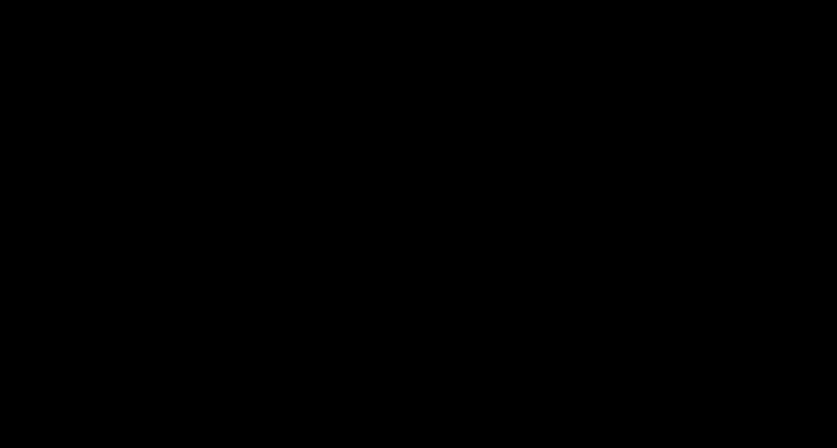

In [9]:
print()
print("\n--- 4.4.2: Comparação entre concelhos Modernizados e Ineficientes ---")

# calcular mediana do rácio de ineficiência
mediana = df_final["Rate_Ineficiencia"].median()

# classificar concelhos
df_final["Grupo"] = np.where(
    df_final["Rate_Ineficiencia"] > mediana,
    "Ineficiente",
    "Modernizado"
)

print("Mediana do rácio de ineficiência:", mediana)
print(df_final["Grupo"].value_counts())

modernizados = df_final[df_final["Grupo"] == "Modernizado"]
ineficientes = df_final[df_final["Grupo"] == "Ineficiente"]

amostra_mod = modernizados.sample(n=30, random_state=42)
amostra_inef = ineficientes.sample(n=30, random_state=42)

util_mod = amostra_mod["Util_Media"]
util_inef = amostra_inef["Util_Media"]

print("\nMédias das amostras:")
print("Modernizados:", util_mod.mean())
print("Ineficientes:", util_inef.mean())

shapiro_mod = shapiro(util_mod)
shapiro_inef = shapiro(util_inef)

print("\nTeste de normalidade (Shapiro-Wilk)")

print("Modernizados p-value:", shapiro_mod.pvalue)
print("Ineficientes p-value:", shapiro_inef.pvalue)

teste = ttest_ind(util_mod, util_inef)

print("\nTeste t para duas amostras independentes")
print("p-value:", teste.pvalue)



--- 4.4.2: Comparação entre concelhos Modernizados e Ineficientes ---
Mediana do rácio de ineficiência: 0.16215572702088152
Grupo
Ineficiente    139
Modernizado    139
Name: count, dtype: int64

Médias das amostras:
Modernizados: 0.5028255848155057
Ineficientes: 0.5183331710820228

Teste de normalidade (Shapiro-Wilk)
Modernizados p-value: 0.13632441131973444
Ineficientes p-value: 0.21893105150294123

Teste t para duas amostras independentes
p-value: 0.3070802286484599
